# Code for CTA sensitivity for for annihilatting DM in the GC

In [1]:
from gammapy.data import DataStore
from gammapy.irf import Background3D

from scipy.interpolate import interp1d
import numpy as np

import math
import astropy
import os
import pandas as pd
import astropy.units as u
from astropy.units import Quantity
import astropy.constants as cst

import matplotlib.pyplot as plt
import pylab
from operator import truediv

from scipy.optimize import fsolve
from scipy import signal
from scipy.integrate import quad, nquad, dblquad, simps, trapz

from gammapy.stats import WStatCountsStatistic
from gammapy.maps import Map, MapAxis
from gammapy.irf import EffectiveAreaTable2D, load_cta_irfs, EnergyDispersion2D
#from gammapy.maps import Map, MapAxis
from astropy.coordinates import SkyCoord

### Importing IRF's

In [2]:
irf_filename = (
"cta-prod5-zenodo-v0.1/fits/CTA-Performance-prod5-v0.1-South-20deg.FITS/Prod5-South-20deg-AverageAz-14MSTs37SSTs.180000s-v0.1.fits.gz"
)
irfs = load_cta_irfs(irf_filename) # Instrument response functions

Let's look to the choosen IRF's:

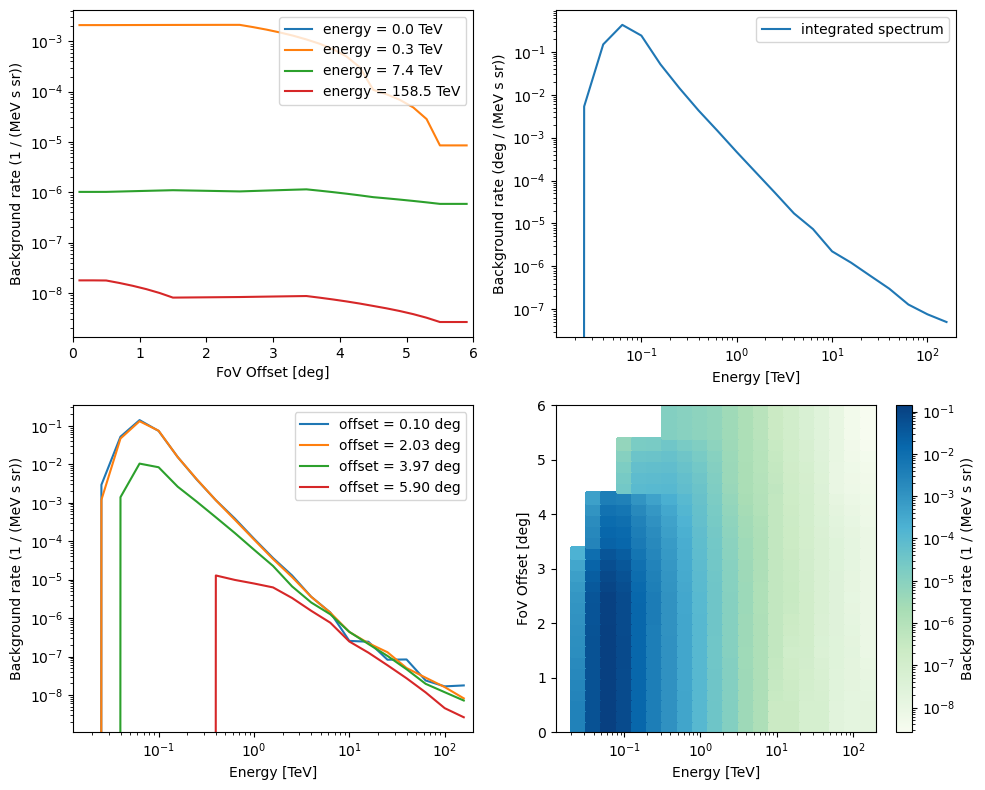

In [3]:
irfs['bkg'].peek()

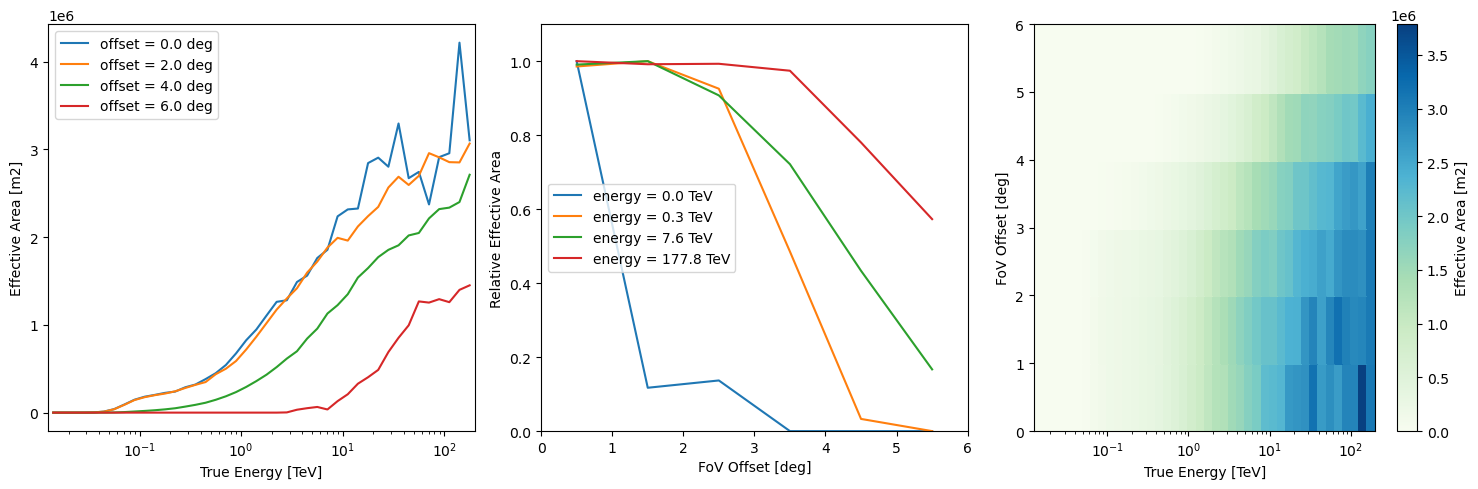

In [4]:
irfs['aeff'].peek()

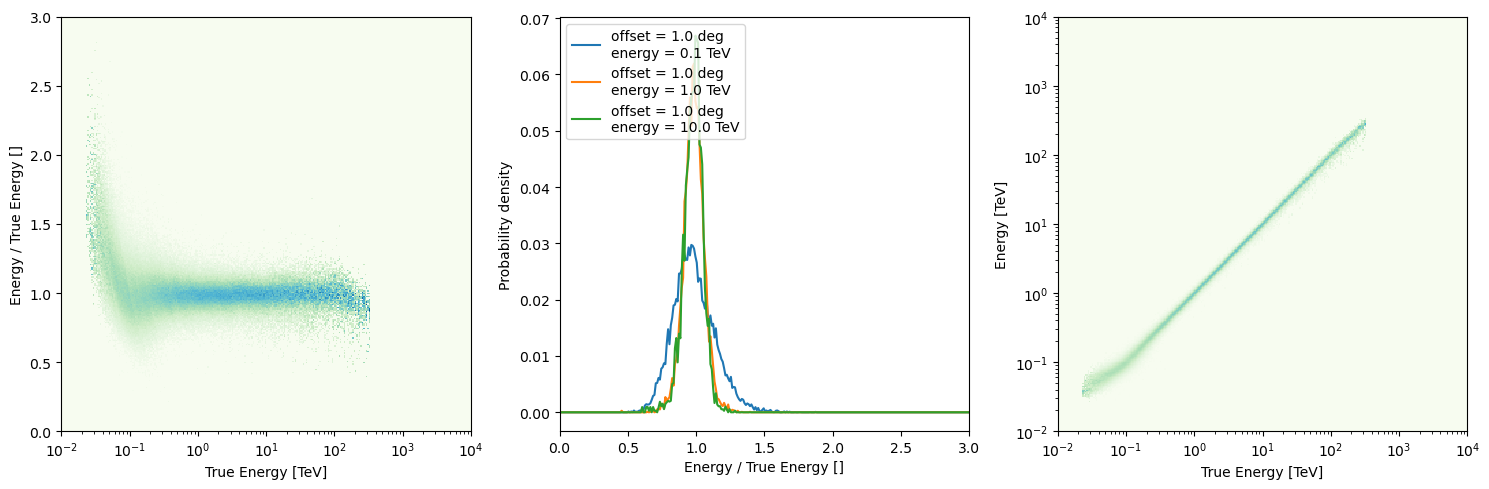

In [5]:
irfs['edisp'].peek()

## Subroutines:

In [6]:
#---functions to set new energy bins------
def bkg_function(e):
    #irfs = load_cta_irfs('/home/lucca/Área de Trabalho/Dark Matter/SEM3.0 - IDM GC/caldb/data/cta/prod3b-v2/bcf/South_z20_50h/irf_file.fits')   
    return float(irfs["bkg"].evaluate(energy="{} TeV".format(e), fov_lon="0 deg", fov_lat="0.5 deg")*u.s*u.sr*u.TeV)
    #used astropy units as to allow quad to integrate, accepts only dimensionless quantities


In [7]:
def bkg_integral(integration_min, integration_max):
    bgrate, error = quad(bkg_function, integration_min, integration_max)#remove energy dependance
    return bgrate # sr^-1 s^-1

In [8]:
def set_energy_bins(min_energy=0.03,max_energy=100,nbins=90):#in TeV
    min_power = np.log10(min_energy) #-1.68#-1.68 #-1.68
    step = (np.log10(max_energy)-min_power)/nbins # 92 130
    # ~ print(step)
    intervals = []
    for count in range(nbins):
        intervals.append([])
        intervals[count].append((10**(min_power+count*step)))#emin
        intervals[count].append((10**(min_power+(count+1)*step)))#emax
    # ~ print(intervals)


    bgrate = []
    for bin_count in range(nbins):
        bgrate.append([bkg_integral(intervals[bin_count][0], intervals[bin_count][1])])
        print('intervals [TeV]:', intervals[bin_count][0], intervals[bin_count][1],'bgrate [s-1*sr-1]',bgrate[bin_count][0])
    return np.array(bgrate), np.array(intervals)#return bg rate per energy bin, energy bins in TeV

In [9]:
def get_effarea(min_energy=0.03,max_energy=100):
    eeff = np.geomspace(min_energy,max_energy,1000)#2.1e-2,1e2,1000
    aeff = []
    for E in eeff:
        aeff.append(irfs['aeff'].evaluate(energy_true=str(E)+" TeV", offset="0.5 deg").to("cm2")*u.cm**(-2))
    Aeff = interp1d(eeff, aeff,bounds_error=False, fill_value=0.)
    return eeff, Aeff # TeV, cm^2


In [10]:
def get_dispersion(bins):
    #bins = np.array(interval)
    (a,b) = np.shape(bins)
    energy = bins.reshape(b*a)
    energy = np.array(sorted(set(energy)))*u.TeV
    #edisp = EnergyDispersion2D.read(irf_filename)
    edisp_kernel = irfs['edisp'].to_edisp_kernel(offset='0.5 deg', energy_true=energy,energy=energy )
    Dispersion = np.array(edisp_kernel.evaluate())
    return Dispersion

In [11]:
def dNdE(spectra_name, mass): # for micrOMEGAs/model dependent data
    lines = []
    with open(spectra_name) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)


    massvals = data["mDM"]
    #index = np.where(np.abs( (massvals - mass) / mass) < 1.e-3)
    index = np.where(massvals == mass)
    Evals = data["E"][index]
    spectrum = data["dNdE"][index]
    #print("Evals",Evals)
    loadspec = interp1d(Evals, spectrum,bounds_error=False, fill_value=0.)# GeV x GeV-1
    E = np.array(sorted(set(Evals)))
    return E[0::round(len(E)/200)], loadspec # E dNdE [0:-1:round(len(mass_total)/20)]

In [12]:
def dNdE_prim(filename,mass,channel): # for Cirelli data
    Gamma = open(filename,'r')
    gamma_header = Gamma.readline().split()
    spectra = []
    for line in Gamma:
        numbers = line.split()
        numbers = [float(n) for n in numbers]
        spectra.append(numbers)

    Gamma.close()
    spectra = np.array(spectra)    
    data = pd.DataFrame(spectra,columns=gamma_header)
    
    #m = (np.abs( (data['mDM'] - mass) / mass) < 5.e-2)
    m = (data['MDM'] == mass)
    gamma = data[m]
    E = np.array(mass*np.power(10,gamma['Log[10,x]']))
    dN = np.array(gamma[channel])#.divide(np.log(10))
    dN = np.divide(dN,E*np.log(10))
 
    loadspec = interp1d(E, dN,bounds_error=False, fill_value=0.)# GeV x GeV-1
    E = np.array(sorted(set(E)))
    #print(len(E),round(len(E)/1000))
    return E[0::round(len(E)/200)], loadspec # GeV, GeV^-1 

In [13]:
def Ns_function(e, interpolarea, flux):#function to integrate ns. observation time is multiplied after return
    #e in TeV
    if(e <= 3e-2):#effective area energy limits (TeV)
        return 0
    if(e >= 1e2):
        return 0

    Ns = interpolarea(e)
    Ns *= (flux(e*1e3)*1e3)
    return Ns
    #return interpolarea(e)*(interpolflux(e*1e3)*1e3) #cm^2*GeV-1*cm-2*s-1 = TeV-1*s-1 

In [14]:
#function to calculate the Ns integral
def Ns_integral(mass, tobs, interval, interpolarea, flux, Evals):#Evals are the energy values used to interpolate flux
    # E in TeV
    integration_max = interval[1]
    integration_min = interval[0]
    if(interval[1] <= Evals[0]/1000):#integration range is below the valid flux range, return 0
        # ~ print('integration range is below the valid flux range, return 0')
        return 0
    if(interval[0] >= mass/1000):#integration range is above the max energy value, return 0
        # ~ print('integration range is above the max energy value, return 0')
        return 0
    if(interval[0] < Evals[0]/1000):#integration is valid, but the minimum has to be increased
        # ~ print('integration is valid, but the minimum has to be increased')
        integration_min = Evals[0]/1000
    if(interval[1] > mass/1000):#the integration is valid but the max value has to be reduced
        # ~ print('the integration is valid but the max value has to be reduced')
        integration_max = mass/1000
    result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))

    return result*tobs

In [15]:
def J_regions(filename):
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
    
    return data['Solid'],data['J'] # region name, solid angle, J-factor

In [16]:
def masses_list(filename_masses): # final version
    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)

    masses_list = np.array(sorted(set(data['MDM'])))
    return masses_list# GeV

In [18]:
def Sigma_CA(filename_masses):
    lines = []
    with open(filename_masses) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
    masses_list = np.array(sorted(set(data['MDM'])))
    sigma_CA = []
    for mass in masses_list:
        sigma = np.mean(np.array(data['SigmaV'][(data['MDM'] == mass)]))
        sigma_CA.append(sigma)
    #sigma_list = np.array(sorted(set(data['SigmaV'])))
    
    return np.array(sigma_CA)



In [19]:
def ID_limits(filename): # final version
    lines = []
    with open(filename) as f:
        for line in f:
            if not line.startswith('#'):
                lines.append(line)
        data = np.genfromtxt (lines, names = True ,dtype = None)
        # ~ print(data.dtype.names)

    sigma = np.array(data['SigmaV'])
    masses = np.array(data['mDM'])
    
    return masses, sigma

In [20]:
def S2(n_off,ns,alpha):
    delta = np.sqrt( (ns-alpha*n_off)**2. + 4.*ns*alpha*n_off/(alpha+1)  )
    S2 = n_off*( np.log( (2.*alpha*n_off/(ns+alpha*n_off+delta))**alpha * (2.*alpha*n_off/(-ns+alpha*n_off+delta)) ) - 0.5*(alpha+1.) ) + (alpha+1.)*((alpha-1.)*ns/(alpha+1.) + delta)/(2.*alpha)  
    return 2.*S2

In [21]:
def TS(n_off,ns,alpha):
    S = 0
    (a,b) = np.shape(n_off)
    (c,d) = np.shape(ns)
    if (c != a or d != b):
        print("Off and Signal data not compatible")
        return 0
    else:
        for region in range(b):
            for interval in range(a):
                off = n_off[interval,region]
                signal = ns[interval,region]
                if (off >= 1 and signal >= 1):
                    currentS = S2(off,signal,alpha)
                    if(currentS < 0):
                        print('currentS is negative')
                    else:
                        S += currentS
                    
                    if(S<0):
                        print('s is negative, somehow', S)
            
    return S

# Reading the IRF's: generating background, bins and matrix dispersion

In [22]:

interval_num = 92 #use custom energy bins

#sigmav = 3*10**-26#cm3/s
#alpha = 1#cta alpha (on/off)
# ~ alpha = 5
tobs = 525*3600#observation time (hours*seconds)
#175, 350, 525


#filename = './Spectrum11.dat'#gamma spectrum filename

#desired_significance = 2.71

#numofprofiles = 1#number of DM profiles in functionlist (rewrite code to allow for multiple)

#intervals = []
bgrate, intervals = set_energy_bins(0.03,100,55)#bg:[1/(s*sr)], intervals:[TeV]
eeff, Aeff = get_effarea()
DispersionMap = get_dispersion(intervals)
#print('bg rates:', bgrate)

intervals [TeV]: 0.029999999999999995 0.034767510584709095 bgrate [s-1*sr-1] 70.02998707867246
intervals [TeV]: 0.034767510584709095 0.04029265974192862 bgrate [s-1*sr-1] 203.95448541344368
intervals [TeV]: 0.04029265974192862 0.04669584913545285 bgrate [s-1*sr-1] 404.28704420662086
intervals [TeV]: 0.04669584913545285 0.05411661430262787 bgrate [s-1*sr-1] 644.1533430205574
intervals [TeV]: 0.05411661430262787 0.06271666535250778 bgrate [s-1*sr-1] 1026.3339755020609
intervals [TeV]: 0.06271666535250778 0.07268341088269908 bgrate [s-1*sr-1] 1272.565044091296
intervals [TeV]: 0.07268341088269908 0.0842340419065667 bgrate [s-1*sr-1] 1198.9295707027354
intervals [TeV]: 0.0842340419065667 0.09762026478597954 bgrate [s-1*sr-1] 1129.0481514605792
intervals [TeV]: 0.09762026478597954 0.11313378630762162 bgrate [s-1*sr-1] 963.9596801872964
intervals [TeV]: 0.11313378630762162 0.13111267043128175 bgrate [s-1*sr-1] 680.4189191670737
intervals [TeV]: 0.13111267043128175 0.1519487052336354 bgrate [

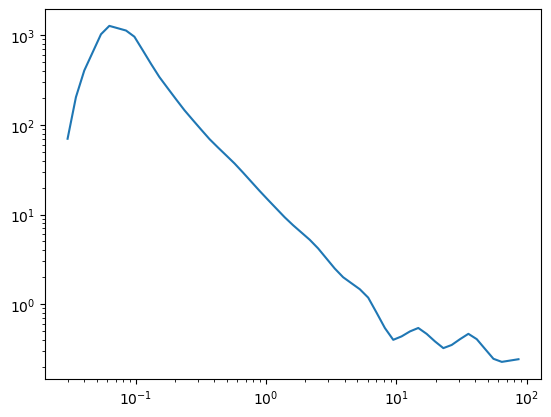

In [23]:
plt.plot(np.array(intervals)[:,0],bgrate)
plt.xscale('log')
plt.yscale('log')

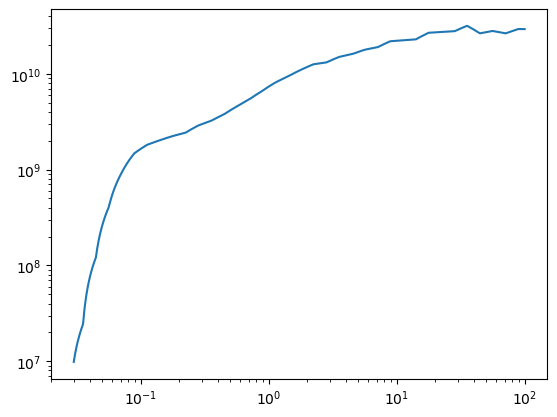

In [24]:
plt.plot(eeff, Aeff(eeff))
plt.xscale('log')
plt.yscale('log')

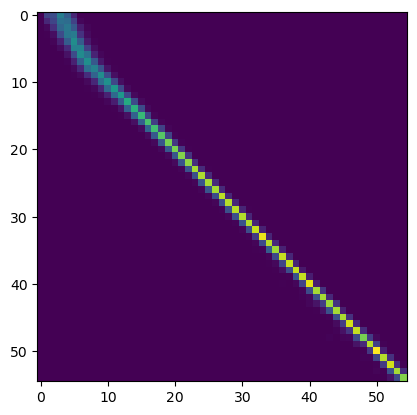

In [25]:
plt.imshow(DispersionMap)

# Spatial and Spectral simulation

In [156]:
B = tobs*bgrate*solid # Background events Bij (expected values = alpha(Noff))

In [157]:
filename_prim = "AtProductionNoEW_gammas.dat"
masses = masses_list(filename_prim)
mass_range = list(masses[0::round(len(masses)/25)])
mass_range.append(masses[-1])
mass_range = np.array(mass_range)
#Use 20 points!
print(mass_range[7:])

[   100    120    140    160    200    240    280    330    400    500
    600    700    800   1000   1200   1500   2000   3000   5000   7000
   9000  12000  20000  50000 100000]


In [158]:

sigma_range = np.logspace(-27,-24,45)**2.
nSV = len(sigma_range)



In [130]:
mass = mass_range[7]
E, loadspec = dNdE_prim(filename_prim,mass,'W')
sigmav0 = 3e-26
J0 = 1e20
C = sigmav0*(8.*np.pi*mass**2.)**-1. *J0

Nt = []

for bin in range(len(intervals)):
    Nt.append([C*Ns_integral(mass, tobs, intervals[bin], Aeff, loadspec, E)])

Nt = np.array(Nt) 
Nr = DispersionMap.T@Nt
Ns = J0**(-1.)*  Nr*J 




/tmp/ipykernel_4899/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_4899/946650164.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


In [131]:
significance = 2.71
TS_range = np.zeros(nSV)
for i in range(nSV):
        #print(sigma_range[i])
        TS_range[i] = TS(B/alpha,(np.sqrt(sigma_range[i])/sigmav0)*Ns,alpha)    
    #print(mass,TS_range)
SigmaV = interp1d(TS_range,sigma_range)  
    #print(TS_range)
sigmalim = np.sqrt(SigmaV(significance))

In [132]:
sigmalim

6.499917927911651e-26

# Sensitivity for primary channels

In [44]:
filename_prim = "AtProductionNoEW_gammas.dat"
filename_prim = "AtProduction_gammas.dat"
masses = masses_list(filename_prim)
mass_range = list(masses[0::round(len(masses)/25)])
mass_range.append(masses[-1])
mass_range = np.array(mass_range)
#Use 20 points!
print(masses[9:])

[    50     60     70     80     90    100    110    120    130    140
    150    160    180    200    220    240    260    280    300    330
    360    400    450    500    550    600    650    700    750    800
    900   1000   1100   1200   1300   1500   1700   2000   2500   3000
   4000   5000   6000   7000   8000   9000  10000  12000  15000  20000
  30000  50000 100000]


In [45]:
J_file = "J_GC_EinastoCTA.dat"
[solid,J] = J_regions(J_file)

tobs = 525*3600
B = tobs*bgrate*solid 

/tmp/ipykernel_5032/3716596546.py:7: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  data = np.genfromtxt (lines, names = True ,dtype = None)


In [47]:
f = open('CTA_bb_EW.dat','w')
f.write('# Indirection Detection Limits\n')
f.write('# Spectrum: PPPC4 bb EW\n')
f.write('#Units: DM mass = GeV, <sigma v> = cm^3 s⁻1\n')
f.write('mDM SigmaV \n')

J0 = 1e20
sigmav0 = 3e-26
sigma_range = np.logspace(-27,-24,15)**2.
nSV = len(sigma_range)

significance = 2.71
alpha = 1.#/6.
CTA_sensitivity_bb = []

for mass in masses[9:]:
    E, loadspec = dNdE_prim(filename_prim,mass,'b')
    C = sigmav0*(8.*np.pi*mass**2.)**-1. *J0

    Nt = []
    for bin in range(len(intervals)):
        Nt.append([C*Ns_integral(mass, tobs, intervals[bin], Aeff, loadspec, E)])

    Nt = np.array(Nt) 
    Nr = DispersionMap.T@Nt
    Ns = J0**(-1.)*  Nr*J 
    
    TS_range = np.zeros(nSV)
    for i in range(nSV):
        #print(sigma_range[i])
        TS_range[i] = TS(B/alpha,(np.sqrt(sigma_range[i])/sigmav0)*Ns,alpha)    
    #print(mass,TS_range)
    SigmaV = interp1d(TS_range,sigma_range)  
    #print(TS_range)
    sigmalim = np.sqrt(SigmaV(significance))
    CTA_sensitivity_bb.append(sigmalim)
    print(mass,sigmalim)
    f.write(str(mass)+' '+str(sigmalim)+'\n')
    
f.close()

/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


50 8.0798287984897185e-25


/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


60 3.6441213253417845e-25


/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


...

30000 4.453401492243443e-26


/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


50000 6.429787081807763e-26


/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_5032/946650164.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


100000 1.1148908074693261e-25


In [35]:
CTA_massWW, CTA_sigmaWW = ID_limits('CTA_official_WW525h.dat')
CTA_massbb, CTA_sigmabb = ID_limits('CTA_official_bb525h.dat')
CTA_masstautau, CTA_sigmatautau = ID_limits('CTA_official_tautau525h.dat')

massWW, sigmaWW = ID_limits('CTA_WW.dat')
massbb, sigmabb = ID_limits('CTA_bb.dat')
masstautau, sigmatautau = ID_limits('CTA_tautau.dat')



Text(0.5, 1.0, 'CTA expected limits to DM')

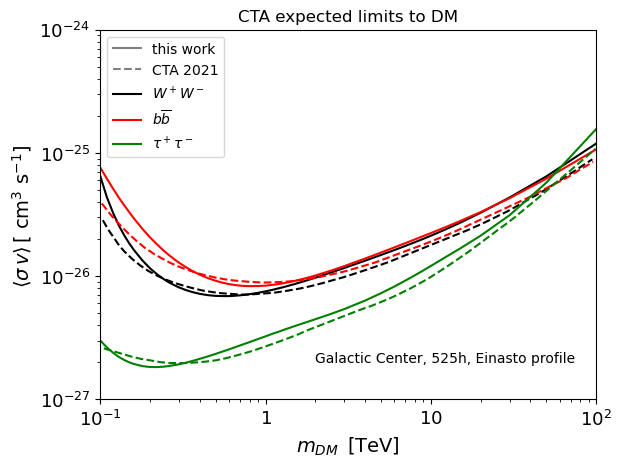

In [48]:
plt.plot([],[],label = 'this work',linestyle='solid',color='gray')
plt.plot([],[],label = 'CTA 2021',linestyle='dashed',color='gray')

plt.plot(CTA_massWW,CTA_sigmaWW,linestyle='dashed',color='black')
plt.plot(massWW,sigmaWW,label=r"$W^+ W^-$",linestyle='solid',color='black')

plt.plot(CTA_massbb,CTA_sigmabb,linestyle='dashed',color='red')
plt.plot(massbb,sigmabb,label=r"$b \overline{b}$",linestyle='solid',color='red')

plt.plot(CTA_masstautau,CTA_sigmatautau,linestyle='dashed',color='green')
plt.plot(masstautau,sigmatautau,label=r"$\tau^+ \tau^-$",linestyle='solid',color='green')

plt.text(2e3,2e-27,'Galactic Center, 525h, Einasto profile')

plt.xlim(1e2,1e5)
plt.ylim(1e-27,1e-24)
plt.xscale('log')
plt.yscale('log')
plt.xticks([1e2,1e3,1e4,1e5],["$10^{-1}$","$1$","$10$","$10^{2}$"],fontsize=13)
plt.yticks([1e-27,1e-26,1e-25,1e-24],["$10^{-27}$","$10^{-26}$","$10^{-25}$","$10^{-24}$"],fontsize=13)
plt.xlabel(r"$ m_{DM} \, $ [TeV] ",fontsize=14)
plt.ylabel(r"$  \left< \sigma \, v \right> \, [$ cm$^3$ s$^{-1}$] ",fontsize=14)


plt.legend(loc='upper left')
plt.title("CTA expected limits to DM")
#plt.savefig("CTA_limits.pdf", bbox_inches = 'tight')

# Sensitivity for one IDM benchmark

In [282]:
J_file = "J_GC_EinastoCTA.dat"
[solid,J] = J_regions(J_file)

tobs = 525*3600
B = tobs*bgrate*solid 


/tmp/ipykernel_4899/3716596546.py:7: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  data = np.genfromtxt (lines, names = True ,dtype = None)


In [284]:
filename = "Spectrum11_all.dat"
mass_range = masses_list("CA_sig_11all")
print(mass_range)

[  554.28   565.36   576.67   588.2    599.97   624.21   636.69   675.66
   689.17   791.64   840.1    856.9   1176.3   1351.2   1491.9   1614.9
  2048.    2702.3   3104.1   3783.9   4015.5   5194.5   5512.5   7567.4
  8030.6  11699.   12415.   18087.   19194.  ]


In [288]:
f = open('ID11.dat','w')
f.write('# Indirection Detection Limits\n')
f.write('# Spectrum: MicrOMEGAs IDMb11\n')
f.write('#Units: DM mass = GeV, <sigma v> = cm^3 s⁻1\n')
f.write('mDM SigmaV \n')

J0 = 1e20
sigmav0 = 3e-26
sigma_range = np.logspace(-27,-24,15)**2.
nSV = len(sigma_range)

significance = 2.71
alpha = 1.#/6.
IDM_sensitivity = []

for mass in mass_range:
    E, loadspec = dNdE(filename,mass)
    C = sigmav0*(8.*np.pi*mass**2.)**-1. *J0

    Nt = []
    for bin in range(len(intervals)):
        Nt.append([C*Ns_integral(mass, tobs, intervals[bin], Aeff, loadspec, E)])

    Nt = np.array(Nt) 
    Nr = DispersionMap.T@Nt
    Ns = J0**(-1.)*  Nr*J 
    
    TS_range = np.zeros(nSV)
    for i in range(nSV):
        #print(sigma_range[i])
        TS_range[i] = TS(B/alpha,(np.sqrt(sigma_range[i])/sigmav0)*Ns,alpha)    
    #print(mass,TS_range)
    SigmaV = interp1d(TS_range,sigma_range)  
    #print(TS_range)
    sigmalim = np.sqrt(SigmaV(significance))
    IDM_sensitivity.append(sigmalim)
    print(mass,sigmalim)
    f.write(str(mass)+' '+str(sigmalim)+'\n')
    
f.close()

/tmp/ipykernel_4899/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_4899/946650164.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


554.28 7.455470737546624e-27
565.36 7.522201693808192e-27
576.67 7.58817668726087e-27
588.2 7.647555093474358e-27
599.97 7.709327370706102e-27
624.21 7.818187970878927e-27
636.69 7.872802536099855e-27
675.66 8.017697626440611e-27
689.17 8.063138100116757e-27
791.64 8.362862841359326e-27
840.1 8.49191491747611e-27
856.9 8.530820500479335e-27
1176.3 9.268977493076249e-27
1351.2 9.664593833706277e-27
1491.9 9.98303972922182e-27
1614.9 1.0256244052041624e-26
2048.0 1.1213490416847548e-26
2702.3 1.2583596821619272e-26
3104.1 1.3379363221748178e-26
3783.9 1.464873160537257e-26
4015.5 1.5062766268817543e-26
5194.5 1.7024947033621824e-26
5512.5 1.751807436602217e-26
7567.4 2.0494709028998213e-26
8030.6 2.1122786343880535e-26
11699.0 2.5741360036063852e-26
12415.0 2.6591307402516434e-26
18087.0 3.309358685667142e-26
19194.0 3.4336675174909774e-26


In [292]:
ID_sensitivity = np.array(ID_sensitivity)

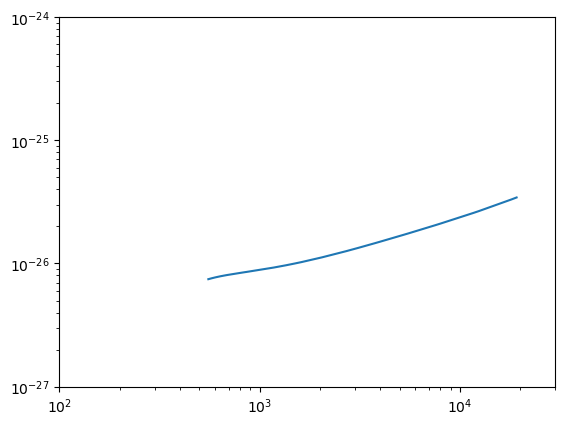

In [294]:
plt.plot(mass_range, IDM_sensitivity)
# plt.plot(temp_ranges, np.mean(new_sigmav, axis = 0))
# plt.fill_between(temp_ranges, np.mean(new_sigmav, axis = 0) + np.std(new_sigmav, axis = 0), np.mean(new_sigmav, axis = 0) - np.std(new_sigmav, axis = 0))
plt.xlim(1e2,3e4)
plt.ylim(1e-27,1e-24)
plt.yscale('log')
plt.xscale('log')

# Sensitivity for all IDM benchmarks

In [26]:
J_file = "J_GC_EinastoCTA.dat"
[solid,J] = J_regions(J_file)

tobs = 525*3600
B = tobs*bgrate*solid 


/tmp/ipykernel_4819/3716596546.py:7: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  data = np.genfromtxt (lines, names = True ,dtype = None)


In [27]:
filenames = [
    './Spectrum11_all.dat','./Spectrum12_all.dat','./Spectrum13_all.dat',
    './Spectrum21_all.dat','./Spectrum22_all.dat','./Spectrum23_all.dat','./Spectrum24_all.dat',
    './Spectrum31_all.dat','./Spectrum32_all.dat','./Spectrum33_all.dat','./Spectrum34_all.dat',
    './Spectrum41_all.dat','./Spectrum42_all.dat','./Spectrum43_all.dat',  
            ] # gamma spectrum filenames

filenames_CA = [
    'CA_sig_11all','CA_sig_12all','CA_sig_13all',
    'CA_sig_21all','CA_sig_22all','CA_sig_23all','CA_sig_24all',
    'CA_sig_31all','CA_sig_32all','CA_sig_33all','CA_sig_34all',
    'CA_sig_41all','CA_sig_42all','CA_sig_43all',  
            ] # correct abundance filenames

benchmark = [
    '11','12','13',
    '21','22','23','24',
    '31','32','33','34',
    '41','42','43'
        ]     # benchmarks

J0 = 1e20
sigmav0 = 3e-26
sigma_range = np.logspace(-27,-24,15)**2.
nSV = len(sigma_range)

significance = 2.71
alpha = 1.#/6.
ID_sensitivity = []

for i in range(14):
    f = open('ID'+benchmark[i]+'.dat', 'w')
    f.write('# Indirection Detection Limits\n')
    f.write('# Spectrum: '+filenames[i]+'\n')
    f.write('#Units: DM mass = GeV, <sigma v> = cm^3 s⁻1\n')
    f.write('mDM SigmaV\n')    
    
    mass_range = masses_list(filenames_CA[i])#[10:20]
    IDi = []    
    
    for mass in mass_range:
        #print(i)
        E, dN = dNdE(filenames[i],mass)
        C = sigmav0*(8.*np.pi*mass**2.)**-1. *J0
        Nt = []
        
        for bin in range(len(intervals)):
            Nt.append([C*Ns_integral(mass, tobs, intervals[bin], Aeff, dN, E)])

        Nt = np.array(Nt) 
        Nr = DispersionMap.T@Nt
        Ns = J0**(-1.)*  Nr*J 
        
        TS_range = np.zeros(nSV)
        for j in range(nSV):
        #print(sigma_range[i])
            TS_range[j] = TS(B/alpha,(np.sqrt(sigma_range[j])/sigmav0)*Ns,alpha)    
        #print(mass,TS_range)
        SigmaV = interp1d(TS_range,sigma_range)  
        #print(TS_range)
        sigmalim = np.sqrt(SigmaV(significance))
        IDi.append(sigmalim)
        f.write(str(mass)+' '+str(sigmalim)+'\n')
    print(i)
    ID_sensitivity.append(IDi)
    f.close()



/tmp/ipykernel_4819/946650164.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))
/tmp/ipykernel_4819/946650164.py:18: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(Ns_function, integration_min, integration_max,  args=(interpolarea, flux))


0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [32]:
J

array([2.867e+20, 5.164e+20, 6.360e+20, 7.350e+20, 7.886e+20, 8.408e+20,
       8.743e+20])